<a href="https://colab.research.google.com/github/HariSharma10/Machine_Leaning/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

   longitude latitude  ...  median_house_value  ocean_proximity
0    -122.23    37.88  ...            452600.0         NEAR BAY
1    -122.22    37.86  ...            358500.0         NEAR BAY
2    -122.24    37.85  ...            352100.0         NEAR BAY
3    -122.25    37.85  ...            341300.0         NEAR BAY
4    -122.25    37.85  ...            342200.0         NEAR BAY

[5 rows x 10 columns]
<class 'pandas.core.frame.DataFrame'>
Index: 26070 entries, 0 to 26070
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           26070 non-null  float64
 1   latitude            26070 non-null  object 
 2   housing_median_age  26070 non-null  float64
 3   total_rooms         26070 non-null  float64
 4   total_bedrooms      25804 non-null  float64
 5   population          26070 non-null  float64
 6   households          26070 non-null  float64
 7   median_income       26070 non-null  float64

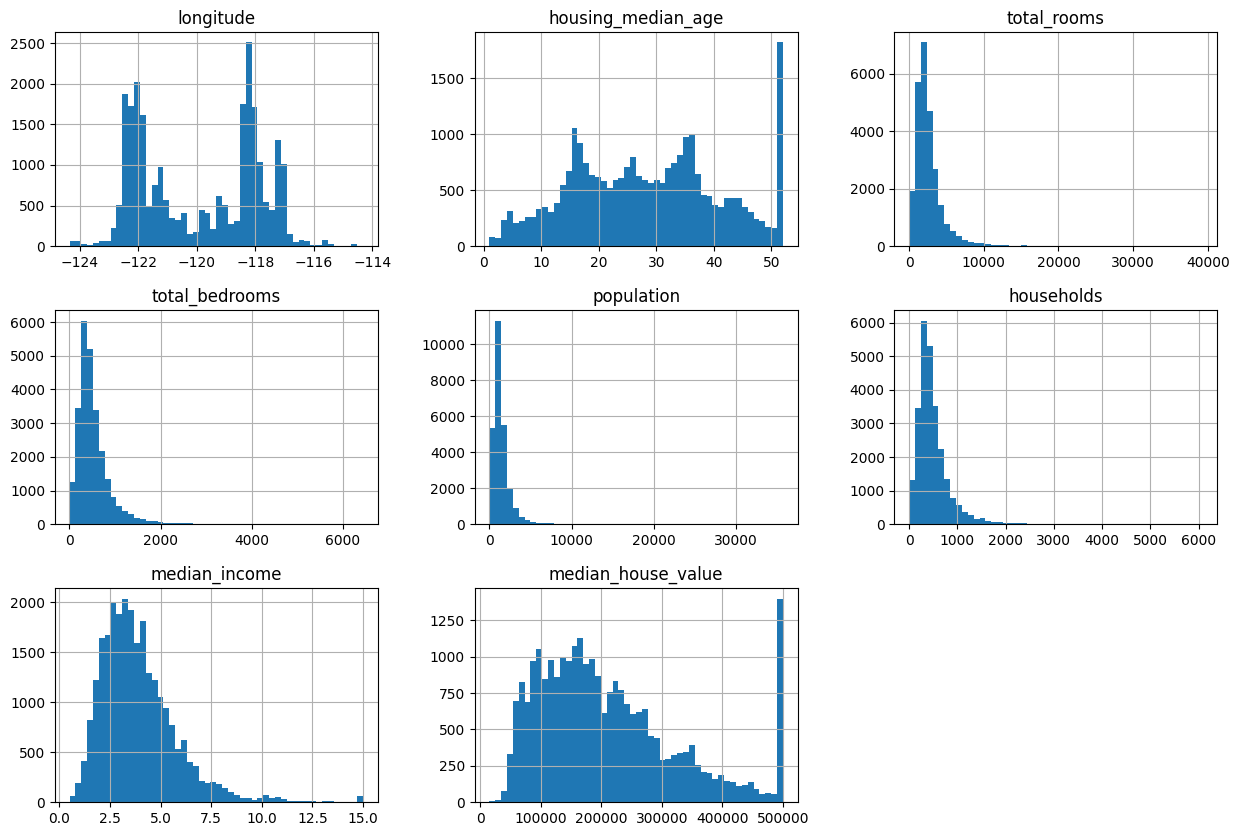

In [7]:





df = pd.read_csv('housing.csv')

# Drop rows where the target (price) is missing
df = df.dropna(subset=['median_house_value'])

print(df.head())
print(df.info())
print(df.isnull().sum())

df.hist(bins=50, figsize=(15,10))
plt.show()

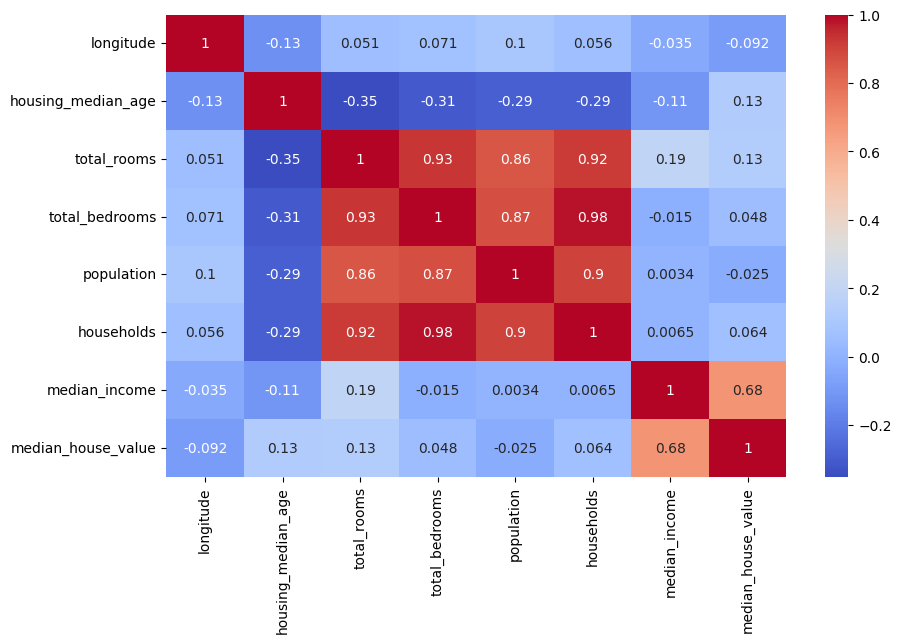

In [8]:
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.show()

In [9]:
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

num_features = X.select_dtypes(include=np.number).columns.tolist()
cat_features = X.select_dtypes(include='object').columns.tolist()

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
        ])
cat_pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
                ('encoder', OneHotEncoder(handle_unknown='ignore'))
                ])
preprocessor = ColumnTransformer([
                    ('num', num_pipeline, num_features),
                        ('cat', cat_pipeline, cat_features)
                        ])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Missing in y_train:", y_train.isnull().sum())  # sanity check, should be 0

Missing in y_train: 0


In [10]:
from sklearn.ensemble import RandomForestRegressor

model = Pipeline([
    ('preprocessor', preprocessor),
        ('regressor', RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
        ])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['longitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['latitude',
                                                   'ocean_proximity'])])),
                ('regressor',
                 RandomForestRegressor(n_estimators=200, n_jobs=-1,
                                       random_state=42))])

In [11]:

y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.4f}")

RMSE: 44451.13
MAE: 27250.18
R2 Score: 0.8530


In [12]:
importances = model.named_steps['regressor'].feature_importances_
feature_names = model.named_steps['preprocessor'].get_feature_names_out()
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
print(feat_imp.head(10))

num__median_income                 0.472161
cat__ocean_proximity_INLAND        0.156927
num__longitude                     0.091516
num__housing_median_age            0.057985
num__population                    0.038545
num__total_bedrooms                0.027020
num__total_rooms                   0.022940
num__households                    0.021591
cat__ocean_proximity_NEAR OCEAN    0.007628
cat__ocean_proximity_<1H OCEAN     0.006201
dtype: float64


In [13]:
import joblib
joblib.dump(model, 'house_price_model.pkl')

from google.colab import files
files.download('house_price_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:



# Load your saved model
model = joblib.load('house_price_model.pkl')

# Enter feature values (must match your original columns exactly)
new_house = pd.DataFrame([{
    'longitude': -122.23,
     'latitude': 37.88,
     'housing_median_age': 41,
      'total_rooms': 880,
      'total_bedrooms': 129,
       'population': 322,
        'households': 126,
        'median_income': 8.3252,
        'ocean_proximity': 'NEAR BAY'
                                    }])

# Predict
predicted_price = model.predict(new_house)
print(f"Predicted house price: ${predicted_price[0]:,.2f}")

Predicted house price: $487,078.77
